In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv("ML_WP_data/train.csv")
test = pd.read_csv("ML_WP_data/test.csv")

In [ ]:
# Checking the table
train.head()

Train shape: (9343, 77)


In [ ]:
# Checking the table
test.head()

,Id,reference_timestamp,fkl010h0_ANT,fkl010h0_BAS,fkl010h0_DAV,fkl010h0_DOL,fkl010h0_GVE,fkl010h0_INT,fkl010h0_LUG,fkl010h0_SIO,...,ure200h0_DAV,ure200h0_DOL,ure200h0_GVE,ure200h0_INT,ure200h0_LUG,ure200h0_SIO,ure200h0_STG,ure200h0_ZER,tre200h0_lag,tre200h0
0,15942,2024-07-20 12:00:00,4.7,1.2,3.8,3.8,2.7,2.3,1.7,2.2,...,47.9,61.0,49.8,49.4,59.3,44.5,60.9,37.2,27.8,28.0
1,16408,2024-12-22 14:00:00,3.6,5.5,1.0,15.6,3.9,5.6,1.7,2.6,...,85.2,99.8,76.8,76.6,87.1,82.0,86.6,86.1,3.8,3.1
2,6441,2015-11-18 07:00:00,1.2,4.1,0.3,10.4,0.9,1.2,1.4,0.6,...,81.1,100.0,94.6,100.0,84.4,89.5,71.6,84.6,4.4,11.7
3,12093,2021-01-14 04:00:00,8.3,6.3,1.1,16.8,1.6,5.0,0.9,3.7,...,92.9,100.0,98.0,100.0,76.5,82.8,90.4,92.2,1.7,4.4
4,6653,2016-01-27 21:00:00,1.7,2.8,0.6,11.1,2.4,0.8,0.3,1.2,...,64.1,51.8,86.8,100.0,89.3,76.2,36.6,63.1,1.4,3.6


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9343 entries, 0 to 9342
Data columns (total 77 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       9343 non-null   int64  
 1   reference_timestamp      9343 non-null   object 
 2   fkl010h0_ANT             9336 non-null   float64
 3   fkl010h0_BAS             9340 non-null   float64
 4   fkl010h0_DAV             9341 non-null   float64
 5   fkl010h0_DOL             9339 non-null   float64
 6   fkl010h0_GVE             9342 non-null   float64
 7   fkl010h0_INT             9341 non-null   float64
 8   fkl010h0_LUG             9342 non-null   float64
 9   fkl010h0_SIO             9341 non-null   float64
 10  fkl010h0_STG             9338 non-null   float64
 11  fkl010h0_ZER             9337 non-null   float64
 12  fkl010h3_ANT             9342 non-null   float64
 13  fkl010h3_BAS             9343 non-null   float64
 14  fkl010h3_DAV            

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2336 entries, 0 to 2335
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2336 non-null   int64  
 1   reference_timestamp  2336 non-null   object 
 2   fkl010h0_ANT         2336 non-null   float64
 3   fkl010h0_BAS         2336 non-null   float64
 4   fkl010h0_DAV         2336 non-null   float64
 5   fkl010h0_DOL         2336 non-null   float64
 6   fkl010h0_GVE         2336 non-null   float64
 7   fkl010h0_INT         2336 non-null   float64
 8   fkl010h0_LUG         2336 non-null   float64
 9   fkl010h0_SIO         2336 non-null   float64
 10  fkl010h0_STG         2336 non-null   float64
 11  fkl010h0_ZER         2336 non-null   float64
 12  fkl010h3_ANT         2336 non-null   float64
 13  fkl010h3_BAS         2336 non-null   float64
 14  fkl010h3_DAV         2336 non-null   float64
 15  fkl010h3_DOL         2336 non-null   f

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,9343.0,10364.390667,3539.481993,3322.0,7248.5,10438.0,13434.500,16430.0
fkl010h0_ANT,9336.0,3.396026,2.570304,0.3,1.1,2.6,5.300,15.1
fkl010h0_BAS,9340.0,1.928844,1.266377,0.0,1.0,1.6,2.400,12.3
fkl010h0_DAV,9341.0,2.240028,1.720647,0.0,0.9,1.7,3.400,10.5
fkl010h0_DOL,9339.0,7.597248,4.136413,0.8,4.4,6.9,10.000,29.4
...,...,...,...,...,...,...,...,...
tre200h0_lag,9341.0,10.141944,8.065895,-14.6,3.8,9.7,16.000,35.5
tre200h0,9341.0,10.180859,8.069617,-12.4,3.8,9.8,16.100,35.5
target_tre200h0_plus12h,9338.0,10.234761,8.151299,-14.5,3.6,10.0,16.300,34.2
target_tre200h0_plus24h,9340.0,10.190996,8.056366,-14.9,3.8,9.9,16.000,34.5


In [ ]:
train.isnull().sum().sort_values(ascending=False)

fkl010h0_ANT    7
fkl010h0_ZER    6
rre150h0_SIO    6
rre150h0_BAS    6
prestah0_LUG    6
               ..
gre000h0_LUG    0
tre200h0_GVE    0
rre150h0_DOL    0
rre150h0_INT    0
ure200h0_LUG    0
Length: 77, dtype: int64

In [4]:
# Getting the variables with missing values and the amount
# Do we check whether missing values are evenly spreaded over all the variables?
missing_counts_train = train.isnull().sum()
missing_counts_train = missing_counts_train[missing_counts_train > 0]
print(missing_counts_train)

fkl010h0_ANT               7
fkl010h0_BAS               3
fkl010h0_DAV               2
fkl010h0_DOL               4
fkl010h0_GVE               1
                          ..
tre200h0_lag               2
tre200h0                   2
target_tre200h0_plus12h    5
target_tre200h0_plus24h    3
target_tre200h0_plus48h    1
Length: 67, dtype: int64


In [5]:
missing_percent_train = (train.isnull().sum() / len(train)) * 100
missing_percent_train = missing_percent_train[missing_percent_train > 0].sort_values(ascending=False)
missing_percent_train


fkl010h0_ANT               0.074922
prestah0_LUG               0.064219
fkl010h0_ZER               0.064219
rre150h0_SIO               0.064219
rre150h0_BAS               0.064219
                             ...   
rre150h0_GVE               0.010703
rre150h0_LUG               0.010703
prestah0_ZER               0.010703
ure200h0_DAV               0.010703
target_tre200h0_plus48h    0.010703
Length: 67, dtype: float64

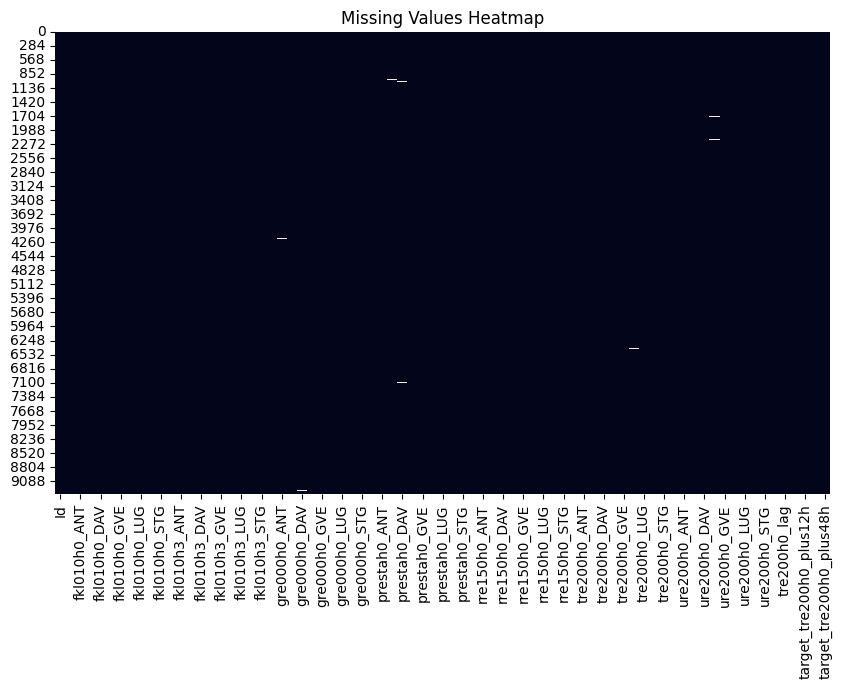

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
test.isnull().sum().sort_values(ascending=False)
# Getting the variables with missing values and the amount
# Do we check whether missing values are evenly spreaded over all the variables?
missing_counts_test = test.isnull().sum()
missing_counts_test = missing_counts_test[missing_counts_test > 0]
print(missing_counts_test)

Series([], dtype: int64)


No need of continuing the Missing values analysis with test dataset, right?